In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
end=pd.Timestamp.now(tz='America/New_York')


start=end-pd.Timedelta(days=30)

current=start
chunks=[]

while current<end:
    chunk_end=min(current+pd.Timedelta(days=7),end)
    df=yf.download("INTC",start=current,
            end=chunk_end,
            interval="1m",
            auto_adjust=False,
            progress=False)
    chunks.append(df)
    current=chunk_end
        


In [ ]:
Stock=pd.concat(chunks)
# Stock['Datetime']
Stock.index=Stock.index.tz_convert('America/New_York')
Data=Stock.between_time('09:30','11:00')
Data['date_5min']=Data.index.floor('5min')
Data['date']=Data.index.date
movement_5min=Data.groupby(by=['date','date_5min']).apply(lambda x:x['Open'].iloc[0, 0] - x['Close'].iloc[-1, 0])
movement_5min = movement_5min.rename('movement_5min')
movement_5min = movement_5min.reset_index()
movement_5min.columns

/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_62519/4044801385.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['date_5min']=Data.index.floor('5min')
/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_62519/4044801385.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['date']=Data.index.date
/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_62519/4044801385.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecat

Index(['date', 'date_5min', 'movement_5min'], dtype='object')

Text(0, 0.5, 'Number of intervals')

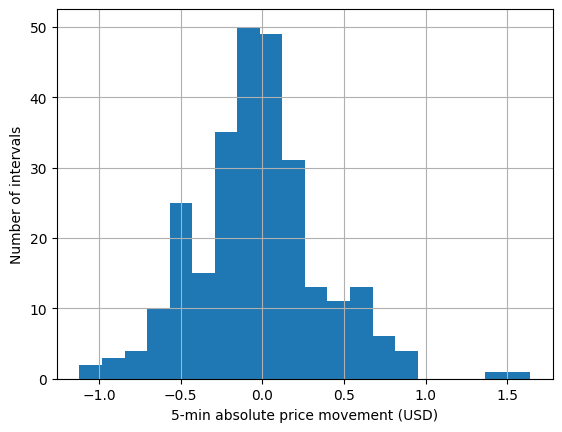

In [ ]:
movement_5min['movement_5min'].hist(bins=20)
plt.xlabel('5-min absolute price movement (USD)')
plt.ylabel('Number of intervals')

(array([20678.16666667, 20682.16666667, 20686.16666667, 20690.16666667,
        20694.16666667, 20697.16666667, 20701.16666667, 20705.16666667]),
 [Text(20678.166666666668, 0, '2026-08-13'),
  Text(20682.166666666668, 0, '2026-08-17'),
  Text(20686.166666666668, 0, '2026-08-21'),
  Text(20690.166666666668, 0, '2026-08-25'),
  Text(20694.166666666668, 0, '2026-08-29'),
  Text(20697.166666666668, 0, '2026-09-01'),
  Text(20701.166666666668, 0, '2026-09-05'),
  Text(20705.166666666668, 0, '2026-09-09')])

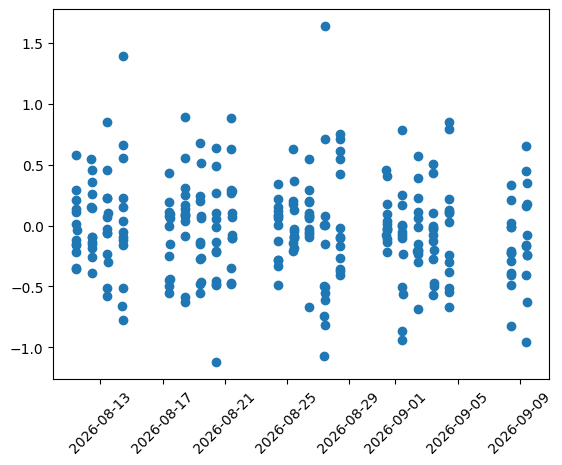

In [ ]:
plt.scatter(movement_5min['date_5min'],movement_5min['movement_5min'])
plt.xticks(rotation=45)
# movement_5min['date_5min']

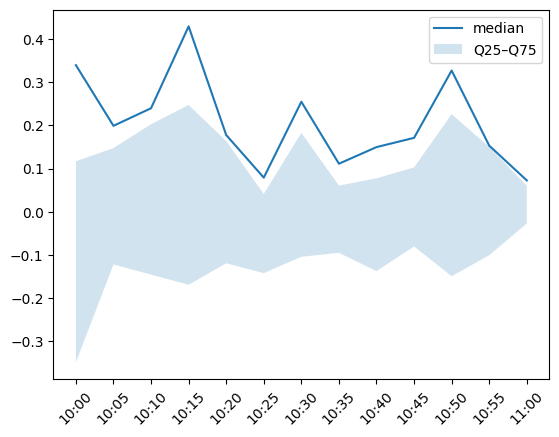

In [ ]:
movement_5min['time'] = movement_5min['date_5min'].dt.strftime('%H:%M')
up=movement_5min[movement_5min['movement_5min']>0]
stats_up = up.groupby('time')['movement_5min'].agg(
    mean='mean',
    median='median',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    count='count'
)
plt.plot(stats_up.index, stats_up['median'], label='median')

plt.fill_between(
    stats_up.index,
    stats_up['q25'],
    stats['q75'],
    alpha=0.2,
    label='Q25–Q75'
)
plt.xticks(rotation=45)
plt.legend()

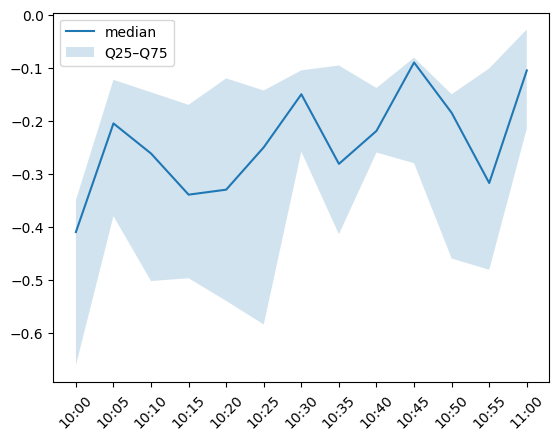

In [ ]:
movement_5min['time'] = movement_5min['date_5min'].dt.strftime('%H:%M')
down=movement_5min[movement_5min['movement_5min']<0]
stats_down = down.groupby('time')['movement_5min'].agg(
    mean='mean',
    median='median',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    count='count'
)
plt.plot(stats_down.index, stats_down['median'], label='median')

plt.fill_between(
    stats_down.index,
    stats_down['q25'],
    stats_down['q75'],
    alpha=0.2,
    label='Q25–Q75'
)
plt.xticks(rotation=45)
plt.legend()

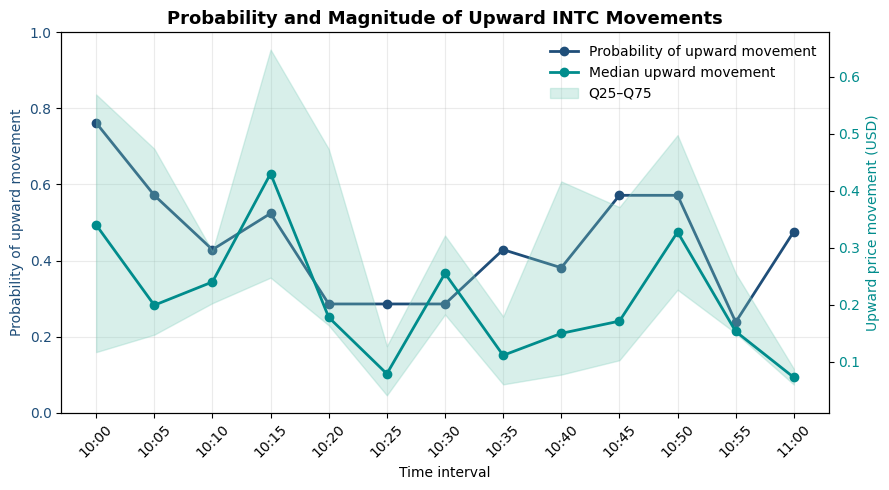

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# bability of upward movement
ax1.plot(
    TOTAL['time'],
    TOTAL['probability_up'],
    marker='o',
    color='#1f4e79',
    linewidth=2,
    label='Probability of upward movement'
)

ax1.set_ylabel(
    'Probability of upward movement',
    color='#1f4e79'
)
ax1.tick_params(axis='y', labelcolor='#1f4e79')
ax1.set_ylim(0, 1)
ax1.set_xlabel('Time interval')

# Median upward movement
ax2 = ax1.twinx()

ax2.plot(
    TOTAL['time'],
    TOTAL['median_up'],
    marker='o',
    color='#008c8c',
    linewidth=2,
    label='Median upward movement'
)

# Interquartile range
ax2.fill_between(
    TOTAL['time'],
    TOTAL['q25_up'],
    TOTAL['q75_up'],
    color='#7fcdbb',
    alpha=0.30,
    label='Q25–Q75'
)

ax2.set_ylabel(
    'Upward price movement (USD)',
    color='#008c8c'
)
ax2.tick_params(axis='y', labelcolor='#008c8c')

ax1.tick_params(axis='x', rotation=45)

ax1.set_title(
    'Probability and Magnitude of Upward INTC Movements',
    fontsize=13,
    fontweight='bold'
)

ax1.grid(alpha=0.25)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right',
    frameon=False
)

plt.tight_layout()

Between 10:00 and 10:05 ET, we observe the highest probability of an upward price movement, at approximately 76%. Conditional on an upward movement, the median increase is about $0.34 per share, with the middle 50% of cases ranging from approximately $0.15 to $0.55.

Another interesting interval is 10:10–10:15 ET, where the probability of an upward movement is about 50%. However, conditional on an increase, the median movement is larger, at approximately $0.43 per share, with the middle 50% of cases ranging from roughly $0.25 to $0.65.

A third potentially favorable window appears between 10:40 and 10:50 ET. The probability of an upward movement is approximately 55–60%, while the median increase ranges from about $0.25 to $0.32 per share, depending on the five-minute interval.